# Response Time Analysis (RTA)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
import scipy.stats as stats
from scipy.stats import levene, boxcox
import statsmodels
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg

## 1. Importing datasets

In [2]:
url2 = 'https://raw.githubusercontent.com/JeroenGuillierme/Project-MDA/main/Data/'

rta_df = pd.read_csv(
    f'{url2}total_df_with_distances.csv')

# Load Belgium with regions shapefile
belgium_with_provinces_boundary = gpd.read_file(f'{url2}BELGIUM_-_Provinces.geojson')

# Setting the style for the plots
sns.set(style="whitegrid")

## 2. Outlier Detection for Response Time T3-T0

Unsupervised learning method, Isolation forest, used. In this case I only care how the model work on the given dataset, and not on new data. So, data splitting is not performed.

In [3]:
interventions_data = rta_df[rta_df['Intervention'] == 1]
print(interventions_data['T3-T0'].isna().sum())

1965


### 2.1 Visualisation distribution Response Times

[Text(0.5, 1.0, 'Logscale of Response Times'), Text(0.5, 0, 'Log(T3-T0)')]

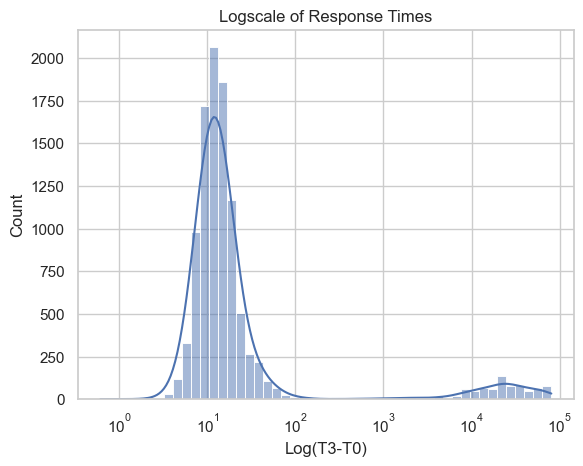

In [4]:
# Plot response times
sns.histplot(data=interventions_data['T3-T0'], bins=50, log_scale=True, kde=True).set(title='Logscale of Response Times', xlabel='Log(T3-T0)') 
# Right-skewed distribution, so log scale was used.

### 2.2 Running Isolation Forest

In [5]:
# Split the DataFrame into two: one with the NaN and one without in the 'T3-T0' column
# DataFrame with NaN values
interventions_data_with_nan = interventions_data[interventions_data['T3-T0'].isna()]  
# DataFrame without NaN values
interventions_data_without_nan = interventions_data[~interventions_data['T3-T0'].isna()]  

print('Without NaN: ', len(interventions_data_without_nan))
print('With NaN: ', len(interventions_data_with_nan))

Without NaN:  10343
With NaN:  1965


In [6]:
Time = interventions_data_without_nan['T3-T0']

# IsolationForest algorithm
IsoFo = IsolationForest(n_estimators=100, contamination='auto',
                        random_state=45)  # Random state added for reproducibility
y_labels = IsoFo.fit_predict(np.array(Time).reshape(-1, 1))

# Only including the inliers
interventions_data_filtered = interventions_data_without_nan[y_labels == 1]  # DataFrame with inliers
discarded_rows = interventions_data_without_nan[y_labels == -1]  # DataFrame with outliers

min_timedelta = discarded_rows['T3-T0'].min()  
max_timedelta = discarded_rows['T3-T0'].max()
min_timedelta2 = interventions_data_filtered['T3-T0'].min()
max_timedelta2 = interventions_data_filtered['T3-T0'].max()
print(f"min response time of outliers: {min_timedelta}") 
print(f"max response time of outliers: {max_timedelta}")
print(f"min response time of inliers: {min_timedelta2}") 
print(f"max response time of inliers: {max_timedelta2}")
print(f"Number of discarded rows: {len(discarded_rows)}")
print(f"Number of filtered rows: {len(interventions_data_filtered)}")


min response time of outliers: 43.78635
max response time of outliers: 80267.83333333333
min response time of inliers: 0.6166666666666667
max response time of inliers: 43.56666666666667
Number of discarded rows: 1047
Number of filtered rows: 9296


In [7]:
print("\nFiltered DataFrame (Inliers):")
interventions_data_filtered.head(5)


Filtered DataFrame (Inliers):


,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province,distance_to_aed,distance_to_ambulance,distance_to_mug,distance_to_pit
0,51.20685,5.13662,1,1.0,18.884917,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,1.239539,3.523140,8.380098,2.792722
1,51.24848,4.43869,1,1.0,4.238700,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.335321,1.454942,1.259929,2.493499
2,51.24848,4.43869,1,1.0,12.612550,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,0.335321,1.454942,1.259929,2.493499
3,51.28273,4.42134,1,1.0,13.427900,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,0.083377,3.262920,3.434839,5.712662
4,51.28273,4.42134,1,1.0,36.619500,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.083377,3.262920,3.434839,5.712662


### 2.3 Total dataset without Response Time outliers

In [8]:
# Add rows with NaN values again:
rta_ready = pd.concat([interventions_data_filtered, interventions_data_with_nan], axis=0)

# Reset index
rta_ready.reset_index(drop=True, inplace=True)

[Text(0.5, 1.0, 'Logscale of Response Times'), Text(0.5, 0, 'Log(T3-T0)')]

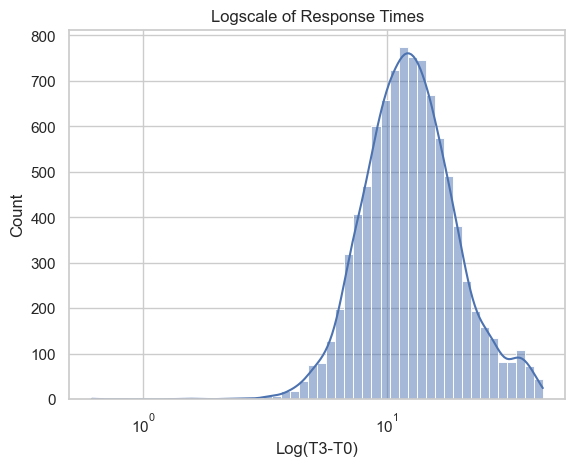

In [9]:
# Plot distribution response times
sns.histplot(data=rta_ready['T3-T0'], bins=50, log_scale=True, kde=True).set(title='Logscale of Response Times', xlabel='Log(T3-T0)') 
# Right-skewed distribution, so log scale was used.

In [10]:
# Last check if no anomalies are left in the dataset

# Get the minimum and maximum values of the 'latitude' column
min_latitude = rta_ready['Latitude'].min()
max_latitude = rta_ready['Latitude'].max()
# Get the minimum and maximum values of the 'longitude' column
min_longitude = rta_ready['Longitude'].min()
max_longitude = rta_ready['Longitude'].max()
# Get the minimum and maximum values of the response time column
min_timedelta = rta_ready['T3-T0'].min()
max_timedelta = rta_ready['T3-T0'].max()

print('Length of dataset: ', len(rta_ready))

print('Number of outliers/anomalies detected: ', len(discarded_rows))
print('Number of inliers: ', len(rta_ready))

print(f"Minimum latitude of dataset: {min_latitude}")
print(f"Maximum latitude of dataset: {max_latitude}")
print(f"Minimum longitude of dataset: {min_longitude}")
print(f"Maximum longitude of dataset: {max_longitude}")
print(f"min_timedelta of dataset: {min_timedelta}")
print(f"max_timedelta of dataset: {max_timedelta}")  

Length of dataset:  11261
Number of outliers/anomalies detected:  1047
Number of inliers:  11261
Minimum latitude of dataset: 49.5114
Maximum latitude of dataset: 51.48203
Minimum longitude of dataset: 2.58552
Maximum longitude of dataset: 6.21838
min_timedelta of dataset: 0.6166666666666667
max_timedelta of dataset: 43.56666666666667


The Isolation Forest algorithm indicated every intervention with a response time longer than 43.5 minutes as an outlier/anomaly.

### 2.4 Visualisation coordinates of intervention locations with outlying Response Time

Most of the interventions with outlying Response Times are found in West-Vlaanderen and Vlaams Brabant.

<Axes: xlabel='Longitude', ylabel='Latitude'>

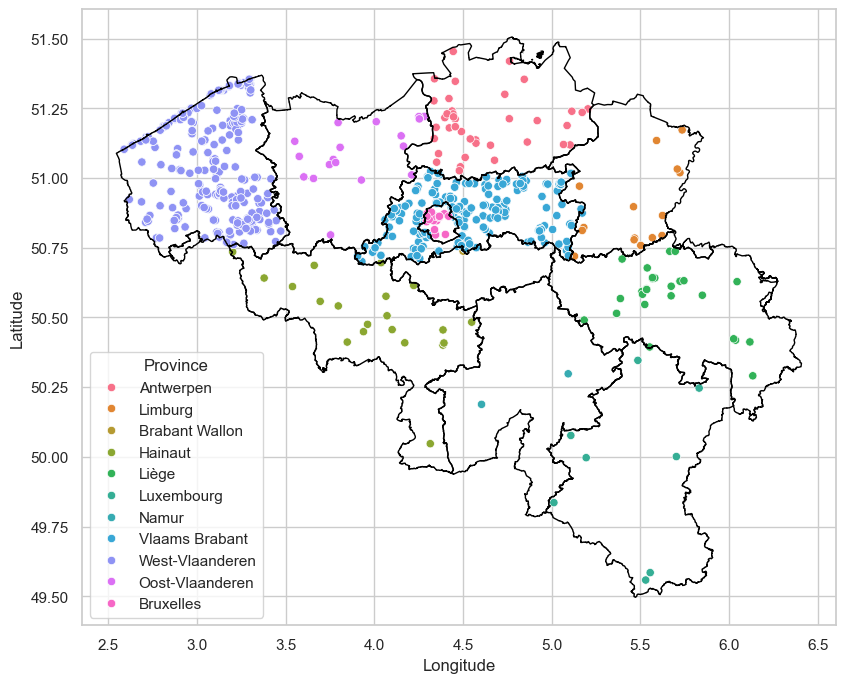

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=discarded_rows, x= 'Longitude', y='Latitude', hue='Province', ax=ax)
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

### 2.5 Visualisation coordinates of intervention locations with inlying Response Times

<Axes: xlabel='Longitude', ylabel='Latitude'>

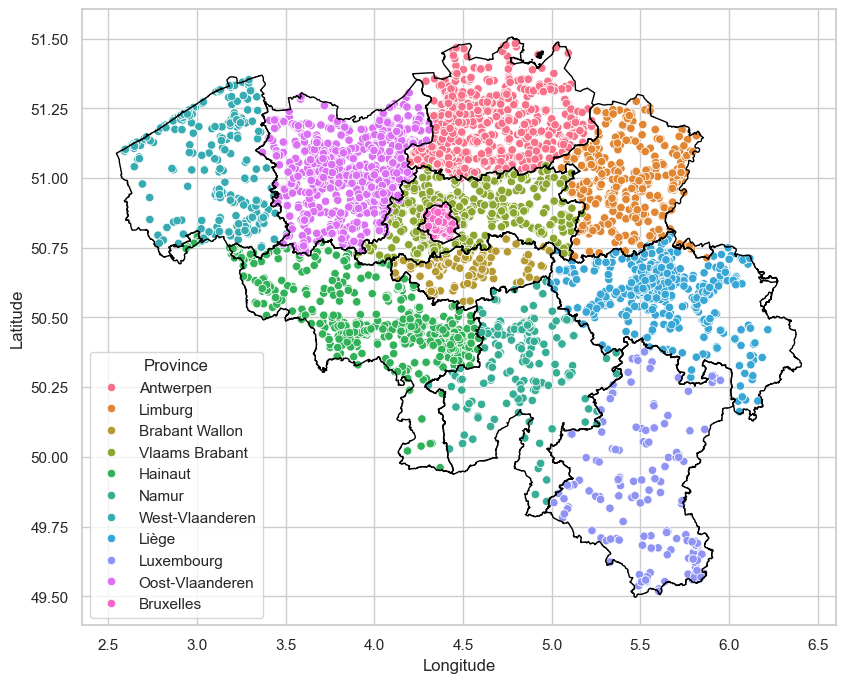

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=interventions_data_filtered, x= 'Longitude', y='Latitude', hue='Province', ax=ax)
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

## 3. Imputing missing Response Times

### 3.1 Visualisation coordinates of intervention locations with no reported Response Times

The dataset is missing  1965 Response Times


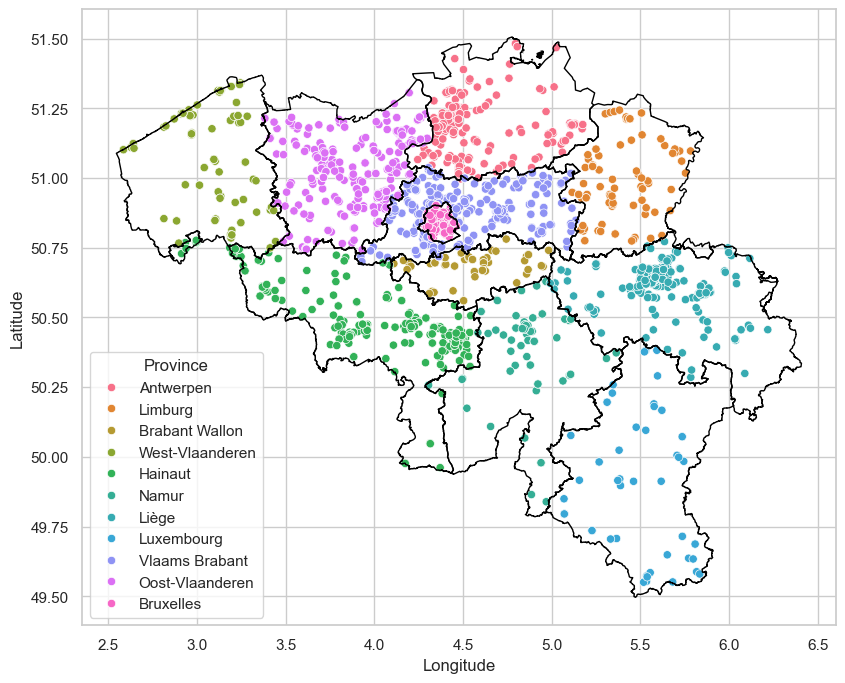

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=interventions_data_with_nan, x= 'Longitude', y='Latitude', hue='Province', ax=ax)
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

print('The dataset is missing ', len(interventions_data_with_nan), 'Response Times')

### 3.2 Replacing Missing Response Times with (KNN) Imputed values Based On Location and Distances
Assign Response Times to intervention locations with no reported Response Time in the dataset using KNN Imputer.

* Feature Selection: Selected Latitude, Longitude,T3-T0 and the calculated distances for imputation. 
* Scaling: No scaling was done whatsoever because the imputed values shouldn’t be affected by scaling, because sometimes extreme values should have an effect on the response time on a certain location. And outlying response times have been removed already.
* KNN Imputation: KNN Imputer applied to the data to fill in the missing values. Again no train and test set was created because it should only work on given dataset and not on new data. This method of imputation uses the k-Nearest Neighbors approach. By default, a euclidean distance metric that supports missing values, is used to find the nearest neighbors
* The imputation was split up over the three different kinds of vector types: Ambulance, MUG and PIT Because, the distance to the closest MUG or PIT location shouldn't influence the imputed response time of an ambulance..

In [14]:
# Split data into the three groups
g1 = rta_ready[rta_ready['Vector type'] == 'Ambulance']
g2 = rta_ready[rta_ready['Vector type'] == 'MUG']
g3 = rta_ready[rta_ready['Vector type'] == 'PIT']
g4 = rta_ready[rta_ready['Vector type'].isna()]
print('Missing values:\n', g4.isna().sum())

# Reset indices of groups
g1.reset_index(drop=True, inplace=True)
g2.reset_index(drop=True, inplace=True)
g3.reset_index(drop=True, inplace=True)

Missing values:
 Latitude                  0
Longitude                 0
Intervention              0
Eventlevel                0
T3-T0                    80
EventType                 0
Vector type              80
AED                       0
Ambulance                 0
Mug                       0
PIT                       0
Province                  0
distance_to_aed           0
distance_to_ambulance     0
distance_to_mug           0
distance_to_pit           0
dtype: int64


Group 4 consists of 80 missing vector types and for each of these observations is the response time also missing.
So, these will be removed from the dataset

In [15]:
# Select features for imputation
# Only include distance to nearest vector type of that group
features_for_imputation1 = g1[['Latitude', 'Longitude', 'distance_to_ambulance', 'T3-T0']]
features_for_imputation2 = g2[['Latitude', 'Longitude', 'distance_to_mug', 'T3-T0']]
features_for_imputation3 = g3[['Latitude', 'Longitude', 'distance_to_pit', 'T3-T0']]

print('Number of observations for the vector types Ambulance, MUG and PIT respectively: \n', 
      len(features_for_imputation1), '\n', len(features_for_imputation2), '\n', len(features_for_imputation3))

Number of observations for the vector types Ambulance, MUG and PIT respectively: 
 5562 
 5237 
 382


In [16]:
# set seed for allowing multiple runs with same outcome
np.random.seed(42)

# Initialize the KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)

# Perform KNN Imputation for each vector type
imputed_values1 = knn_imputer.fit_transform(features_for_imputation1)
imputed_values2 = knn_imputer.fit_transform(features_for_imputation2)
imputed_values3 = knn_imputer.fit_transform(features_for_imputation3)

# Create a dataframes with the imputed values
imputed_data1 = pd.DataFrame(imputed_values1, columns=['Latitude', 'Longitude', 'distance_to_ambulance', 'T3-T0'])
imputed_data2 = pd.DataFrame(imputed_values2, columns=['Latitude', 'Longitude', 'distance_to_mug', 'T3-T0'])
imputed_data3 = pd.DataFrame(imputed_values3, columns=['Latitude', 'Longitude', 'distance_to_pit', 'T3-T0'])


### 3.3 Assigning imputed Response Times back to original dataframes and concatenate them back together

In [17]:
g1.loc[:,'T3-T0'] = imputed_data1['T3-T0']
g2.loc[:,'T3-T0'] = imputed_data2['T3-T0']
g3.loc[:,'T3-T0'] = imputed_data3['T3-T0']

rta_ready = pd.concat([g1, g2, g3], axis=0, ignore_index=True) # Group 4 isn't concatenated, leaving these observations behind for further analysis
print('Missing values: \n', rta_ready.isna().sum())

Missing values: 
 Latitude                  0
Longitude                 0
Intervention              0
Eventlevel                0
T3-T0                     0
EventType                 0
Vector type               0
AED                       0
Ambulance                 0
Mug                       0
PIT                       0
Province                 26
distance_to_aed           0
distance_to_ambulance     0
distance_to_mug           0
distance_to_pit           0
dtype: int64


### 3.4 Visualisation distribution imputed Response Times

[Text(0.5, 1.0, 'Logscale of Imputed Response Times'),
 Text(0.5, 0, 'Log10(T3-T0)')]

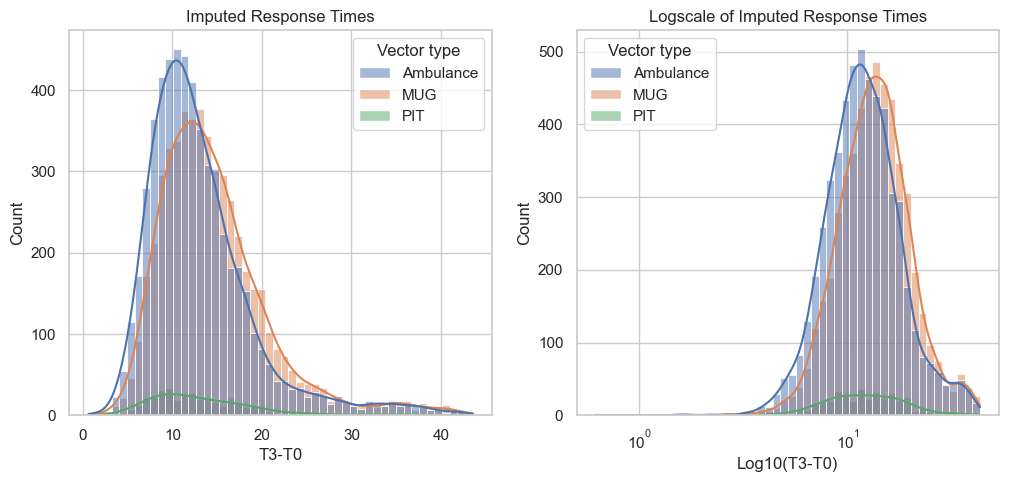

In [18]:
# Plot response times
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=rta_ready, x='T3-T0', bins=50, log_scale=False, kde=True, hue='Vector type',ax=axes[0]).set(
    title='Imputed Response Times', xlabel='T3-T0') 
sns.histplot(data=rta_ready, x='T3-T0', bins=50, log_scale=True, kde=True, hue='Vector type',ax=axes[1]).set(
    title='Logscale of Imputed Response Times', xlabel='Log10(T3-T0)') 
# Right-skewed distribution, so log scale was used.

<Axes: xlabel='Longitude', ylabel='Latitude'>

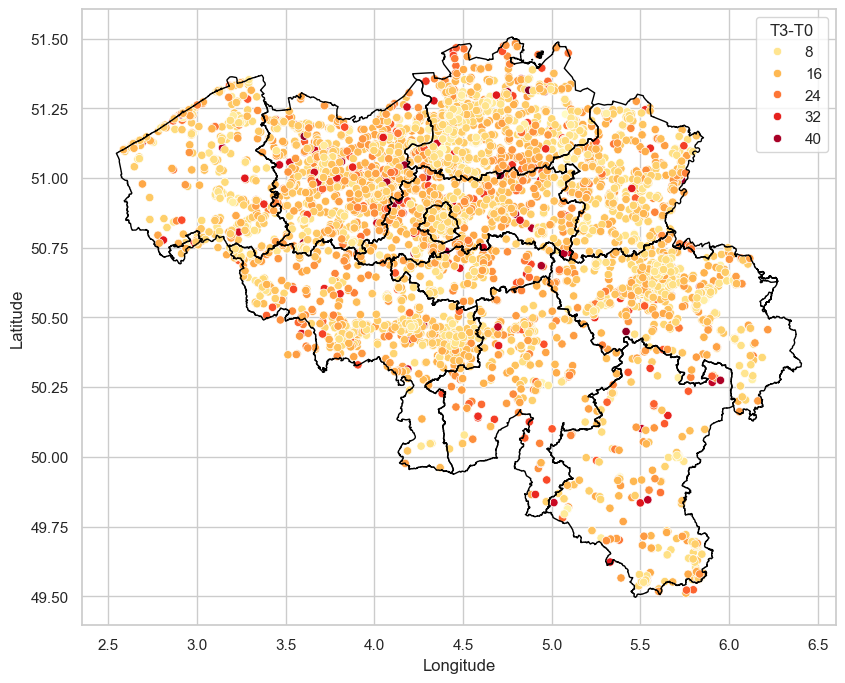

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=rta_ready, x= 'Longitude', y='Latitude', hue='T3-T0', palette='YlOrRd', ax=ax)
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

## 4. Split up Response Times in three categories: Short, Medium and Long 

According to the literature, the ambulance response time is divided into 3 categories:
short (<4 min), medium (4-8 min), and long (>8 min). 
If the accident is in a multi-store building, this time will include some additional time called vertical response time. 
Vertical response time includes time interval from arrival on-scene to arrival at the patient's side.
Although shorter ambulance response time can increase medical effectiveness and satisfaction, 
it may reduce productivity due to the resources required and increased costs.

(link: https://www.researchgate.net/publication/362523045_Assessment_of_Ambulance_Response_Time_A_Study_of_Tabriz_Emergency_Medical_Center_Tabriz_City_Iran/fulltext/62fbbc80e3c7de4c34605bf1/Assessment-of-Ambulance-Response-Time-A-Study-of-Tabriz-Emergency-Medical-Center-Tabriz-City-Iran.pdf?origin=scientificContributions ).

In [20]:
# Create new column RT_category conatining the three categories
# Initialize the RT_category column with an empty string
rta_ready['RT_category'] = ''

# Apply the categorization
rta_ready.loc[rta_ready['T3-T0'] < 4, 'RT_category'] = 'Short (<4 min)'
rta_ready.loc[(rta_ready['T3-T0'] >= 4) & (rta_ready['T3-T0'] <= 8), 'RT_category'] = 'Medium (4-8 min)'
rta_ready.loc[rta_ready['T3-T0'] > 8, 'RT_category'] = 'Long (>8 min)'

In [21]:
# Create a table counting the number of interventions per Response Time category
counts = rta_ready.loc[:,'RT_category'].value_counts
pd.merge(counts(normalize=False), counts(normalize=True), left_index=True, right_index=True)

,count,proportion
RT_category,,
Long (>8 min),9772,0.873983
Medium (4-8 min),1366,0.122172
Short (<4 min),43,0.003846


### 4.1 Saving Imputed data without outliers to new dataset

In [60]:
#rta_ready.to_csv('Data/rta_df.csv', index=False)

## 5. Comparing Response Times between different groups

In [23]:
# Renaming some variables for performing ANOVA
rta_anova = rta_ready
rta_anova['response_time'] = rta_anova['T3-T0']
rta_anova['vector_type'] = rta_anova['Vector type']

### 5.1 Response Time versus Vector type (Ambulance, MUG or PIT)

#### 5.1.1 Summary Statistics & Visualisation

In [24]:
# Initialize dataset for comparison between vector type
rta_anova_vt = rta_anova[['response_time', 'vector_type']].dropna()
rta_anova_vt.reset_index(drop=True, inplace=True) # Reset index 

# Log-Transform the variable Response Time, because is right-skewed
rta_anova_vt['log_response_time'] = rta_anova_vt['response_time'].transform(np.log10)

print(len(rta_anova),len(rta_anova_vt))

11181 11181


In [25]:
# Basics Statistics per Group
rta_anova_vt.groupby('vector_type')['response_time'].describe()

,count,mean,std,min,25%,50%,75%,max
vector_type,,,,,,,,
Ambulance,5562.0,13.091420,6.064285,0.616667,9.139948,11.832650,15.333333,43.566667
MUG,5237.0,14.598828,6.193447,0.616667,10.356150,13.466667,17.266290,43.566667
PIT,382.0,13.236115,5.890673,1.320917,9.042054,12.033333,16.437500,41.600000


Text(0, 0.5, 'Response Time')

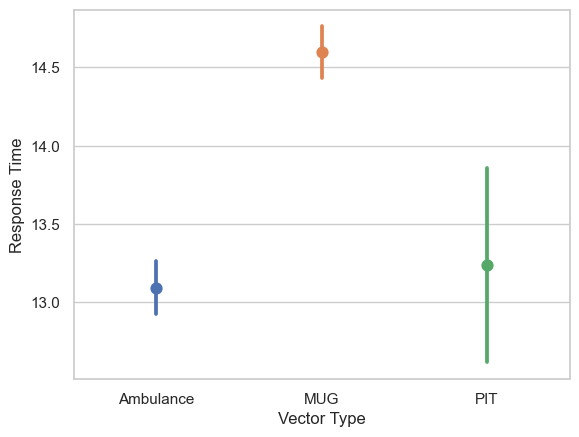

In [26]:
sns.pointplot(x='vector_type', y = 'response_time', data = rta_anova_vt, hue='vector_type') # errorbars: 95% confidence interval
plt.xlabel('Vector Type')
plt.ylabel('Response Time')

#### 5.1.2 Perform Analysis

In [27]:
# ANOVA
formula1 = 'log_response_time ~ vector_type'
model1 = ols(formula1, data=rta_anova_vt).fit()
anova_table1 = sm.stats.anova_lm(model1, typ=2)
anova_table1

,sum_sq,df,F,PR(>F)
vector_type,7.403521,2.0,115.719763,1.806139e-50
Residual,357.573137,11178.0,NaN,NaN


In [28]:
# Post-hoc test if ANOVA is significant
# Tukey's honestly significantly differneced (HSD) test
# H0: No significant difference between the means of two groups
if anova_table1['PR(>F)'].iloc[0] < 0.05:
    tukey1 = pairwise_tukeyhsd(rta_anova_vt['log_response_time'], rta_anova_vt['vector_type'], alpha=0.05)

tukey1.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Ambulance,MUG,0.0518,0.0,0.0438,0.0599,True
Ambulance,PIT,0.0048,0.8701,-0.0174,0.0269,False
MUG,PIT,-0.0471,0.0,-0.0693,-0.0249,True


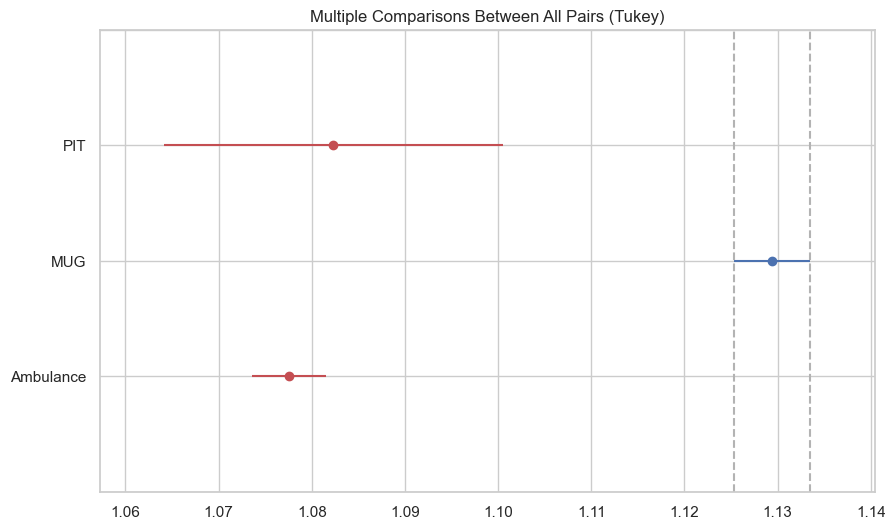

In [29]:
# Plot group confidence intervals
tukey1.plot_simultaneous(comparison_name='MUG'); 

#### 5.1.3 Checking Model Assumptions

**Assumptions of ANOVA**
The ANOVA test has important assumptions that must be satisfied in order for the associated p-value to be valid.
* The samples are independent.
* Each sample is from a normally distributed population.
* The population standard deviations of the groups are all equal. This property is known as homoscedasticity.

**Normality Of Residuals**

Seems like normailty is mostly violated in the tails of the distribution.

Kolmogorov-Smirnov Test: p-value = 0.0
Residuals do not appear to be normally distributed (reject H0).


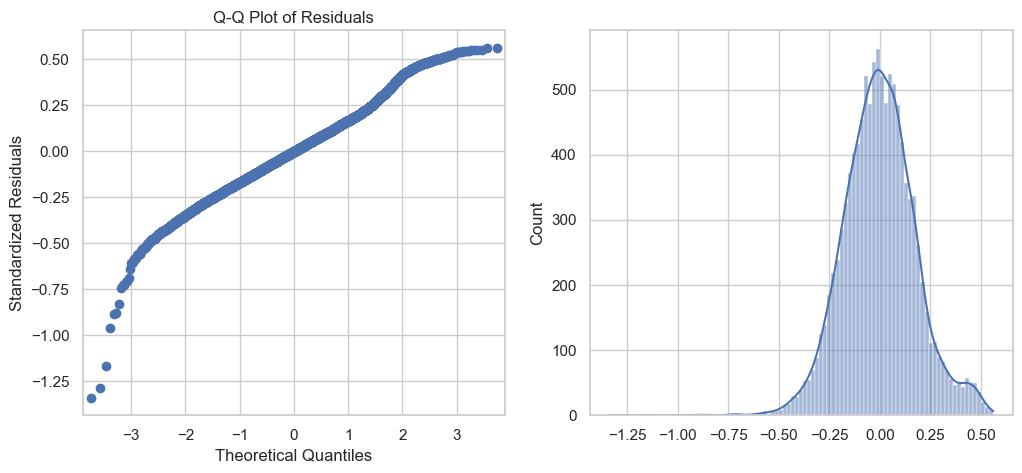

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normality of residuals with QQ-plot
residuals1 = model1.resid
sm.qqplot(residuals1, ax=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].set_xlabel("Theoretical Quantiles")
axes[0].set_ylabel("Standardized Residuals")

# Histogram
sns.histplot(residuals1, kde=True, ax=axes[1])

# Perform the Kolmogorov-Smirnov test for normality, because large dataset
ks_test1 = stats.kstest(residuals1, 'norm')

# Print the p-value
print('Kolmogorov-Smirnov Test: p-value =', ks_test1.pvalue)

# Interpret the result
if ks_test1.pvalue > 0.05:
    print("Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Residuals do not appear to be normally distributed (reject H0).")

**Homogeneity Of Variances**

p-value of the levene test:  0.0074794014967508125
Variances across groups are not equal (reject H0).


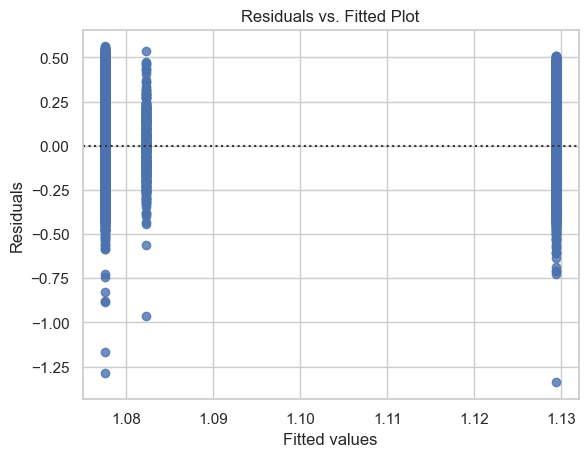

In [31]:
# Residuals vs Fitted Plot
fitted_vals1 = model1.fittedvalues
sns.residplot(x=fitted_vals1, y=residuals1, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Plot')


# Levene's test
# H0: population variances across groups are eaqual
levene_test1 = levene(rta_anova_vt['log_response_time'][rta_anova_vt['vector_type'] == 'Ambulance'],
                     rta_anova_vt['log_response_time'][rta_anova_vt['vector_type'] == 'MUG'],
                     rta_anova_vt['log_response_time'][rta_anova_vt['vector_type'] == 'PIT'])
print('p-value of the levene test: ', levene_test1[1])
# Interpret the result
if levene_test1.pvalue > 0.05:
    print("Variances across groups are equal (fail to reject H0).")
else:
    print("Variances across groups are not equal (reject H0).")

#### 5.1.4 Welch's ANOVA as alternative

**(Re)test Homogeneity of variances between the groups**

In [32]:
# Divide data in groups
vt1 = rta_anova_vt[rta_anova_vt['vector_type'] == 'Ambulance']
vt2 = rta_anova_vt[rta_anova_vt['vector_type'] == 'MUG']
vt3 = rta_anova_vt[rta_anova_vt['vector_type'] == 'PIT']

# Perform Bartlett's test to test homogeneity of variances between groups
barlett1 = stats.bartlett(vt1['log_response_time'], vt2['log_response_time'], vt3['log_response_time'])

print('p-value =', barlett1.pvalue) # Rejected: assumption of equal variances is violated

p-value = 0.00033071115940111413


**Welch's ANOVA if Homogeneity of Variances Rejected**

In [33]:
# Apply Welch's ANOVA
if barlett1.pvalue < 0.05:
    welch1 = pg.welch_anova(dv='log_response_time', between='vector_type', data=rta_anova_vt)
welch1 # p-unc is the p-value; here: very small => reject the null hypothesis that the response time are equal between the three vector types.

,Source,ddof1,ddof2,F,p-unc,np2
0,vector_type,2,1040.842913,116.474013,2.250560e-46,0.020285


**Post-Hoc Games Howell test if Welch's ANOVA significant**

In [34]:
# If Welch's ANOVA significant:
# Games-Howell Post Hoc test for Welch's ANOVA
if welch1['p-unc'][0] < 0.05:
    gh1 = pg.pairwise_gameshowell(dv='log_response_time', between='vector_type', data=rta_anova_vt)
gh1

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Ambulance,MUG,1.077565,1.129411,-0.051845,0.003433,-15.102855,10796.233417,5.268785e-12,-0.290327
1,Ambulance,PIT,1.077565,1.082319,-0.004753,0.009874,-0.481375,432.661287,8.801572e-01,-0.025938
2,MUG,PIT,1.129411,1.082319,0.047092,0.009862,4.775301,430.400481,7.351120e-06,0.269564


**Visualization of the p-values in the form of a Heatmap**

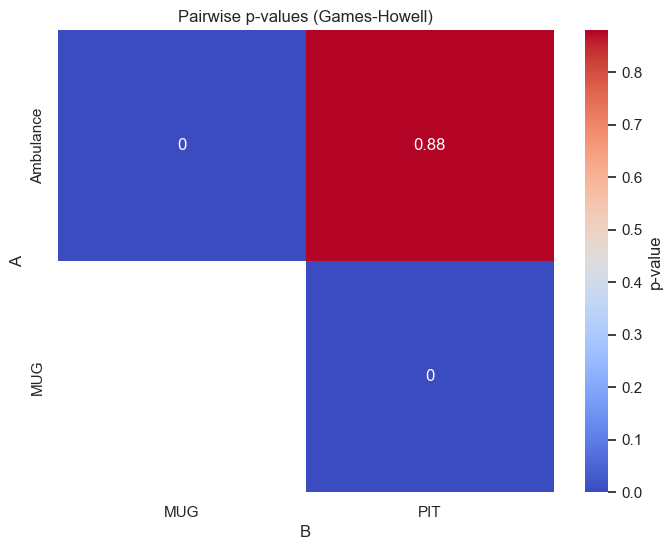

In [35]:
# Visualize p-values in the form of a heatmap
# Pivot the results to get the p-values
pval_matrix1 = gh1.pivot(index='A', columns='B', values='pval').round(3)

# Plot the heatmap
sns.set(style='white')
plt.figure(figsize=(8, 6))
sns.heatmap(pval_matrix1, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
plt.title('Pairwise p-values (Games-Howell)')
plt.show()

After checking the model assumptions for a one-way ANOVA, we saw that the normality of the residuals and the homogeneity of the variances between the vector types weren't equal. So, the results of the ANOVA may be incorrect or misleading. 

Because the homogeneity was not met (see also Barlett's test) an alternative test was performed, namely the Welch's ANOVA. This test gave, just as the one-way ANOVA a significant result, indicatin gthe (mean) response time for the different vector types aren't equal. As post hoc test, a Games-Howell test was run to see where the differences are.

**Result**

Only the mean response time for the vector type MUG differs significantly from these of the Ambulances and PITs. The mean response times for MUGs are almost 15 minutes, which is longer than the other vector types.

### 5.2 Response Time versus Province

#### 5.2.1 Summary Statistics & Visualisation

In [36]:
# Discard rows with Missing Values for vector type
rta_anova_prov = rta_anova[['response_time', 'Province']].dropna()
rta_anova_prov.reset_index(drop=True, inplace=True) # Reset index after dropping missing values

# Log-Transform the variable Response Time, because is right-skewed
rta_anova_prov['log_response_time'] = np.log10(rta_anova_prov['response_time']) # Create new column for transformed response times

print(len(rta_anova),len(rta_anova_prov)) # 26 observations with missing province removed

11181 11155


In [37]:
# Basics Statistics per Group
rta_anova_prov.groupby('Province')['response_time'].describe()

,count,mean,std,min,25%,50%,75%,max
Province,,,,,,,,
Antwerpen,2245.0,12.390441,5.947518,1.320917,8.596550,11.115250,14.322917,43.254500
Brabant Wallon,244.0,13.827945,6.093077,4.002150,9.643067,12.417768,16.445115,39.465983
Bruxelles,543.0,12.609585,6.078646,2.167375,9.109558,11.208455,14.010301,42.837061
Hainaut,1230.0,13.505454,5.159230,2.253300,10.034032,12.564982,15.890196,39.439900
Limburg,839.0,13.120508,5.674570,1.572733,9.278775,12.150600,15.436367,40.902767
Liège,1360.0,12.591771,5.334449,0.809817,9.032479,11.492433,14.986221,42.613933
Luxembourg,347.0,14.690664,7.261045,4.052067,9.287205,13.155267,18.303733,39.883517
Namur,434.0,13.888334,6.098750,3.116183,9.613008,12.773203,16.652433,38.256833
Oost-Vlaanderen,2154.0,14.863963,6.371524,3.333333,10.404167,13.783333,17.466667,42.050000


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Antwerpen'),
  Text(1, 0, 'Limburg'),
  Text(2, 0, 'Brabant Wallon'),
  Text(3, 0, 'Vlaams Brabant'),
  Text(4, 0, 'Hainaut'),
  Text(5, 0, 'Namur'),
  Text(6, 0, 'West-Vlaanderen'),
  Text(7, 0, 'Liège'),
  Text(8, 0, 'Luxembourg'),
  Text(9, 0, 'Oost-Vlaanderen'),
  Text(10, 0, 'Bruxelles')])

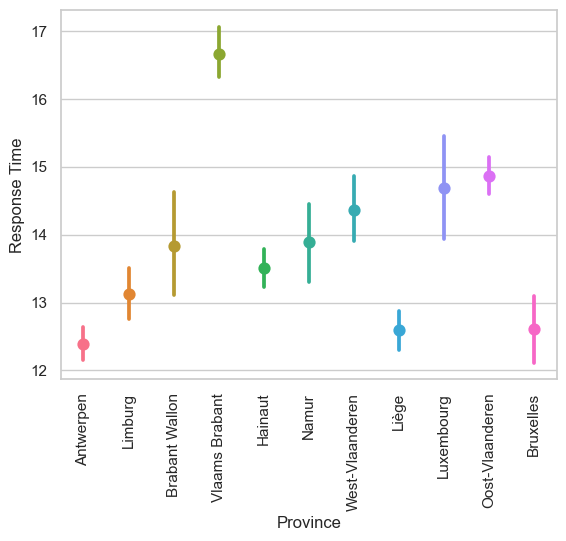

In [38]:
sns.set(style='whitegrid')
sns.pointplot(x='Province', y = 'response_time', data = rta_anova_prov, hue='Province') # errorbars: 95% confidence interval
plt.ylabel('Response Time')
plt.xticks(rotation=90)

#### 5.2.2 Perform Analysis

In [39]:
# ANOVA
formula2 = 'log_response_time ~ Province'
model2 = ols(formula2, data=rta_anova_prov).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)
anova_table2

,sum_sq,df,F,PR(>F)
Province,20.421976,10.0,66.279302,6.319111e-132
Residual,343.368879,11144.0,NaN,NaN


In [40]:
# Post-hoc test if ANOVA is significant
# Tukey's honestly significantly differneced (HSD) test
# H0: No significant difference between the means of two groups
if anova_table2['PR(>F)'].iloc[0] < 0.05:
    tukey2 = pairwise_tukeyhsd(rta_anova_prov['log_response_time'], rta_anova_prov['Province'], alpha=0.05)

tukey2.summary()

C:\Users\Admin\Documents\MDA 2de zit\MDA24\Lib\site-packages\scipy\integrate\_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


group1,group2,meandiff,p-adj,lower,upper,reject
Antwerpen,Brabant Wallon,0.0511,0.0008,0.013,0.0892,True
Antwerpen,Bruxelles,0.0109,0.9687,-0.0161,0.038,False
Antwerpen,Hainaut,0.0496,0.0,0.0295,0.0696,True
Antwerpen,Limburg,0.0301,0.0012,0.0072,0.0529,True
Antwerpen,Liège,0.0141,0.403,-0.0053,0.0336,False
Antwerpen,Luxembourg,0.0658,0.0,0.0332,0.0984,True
Antwerpen,Namur,0.0516,0.0,0.022,0.0812,True
Antwerpen,Oost-Vlaanderen,0.0854,0.0,0.0684,0.1025,True
Antwerpen,Vlaams Brabant,0.138,0.0,0.1175,0.1586,True
Antwerpen,West-Vlaanderen,0.0718,0.0,0.0462,0.0974,True


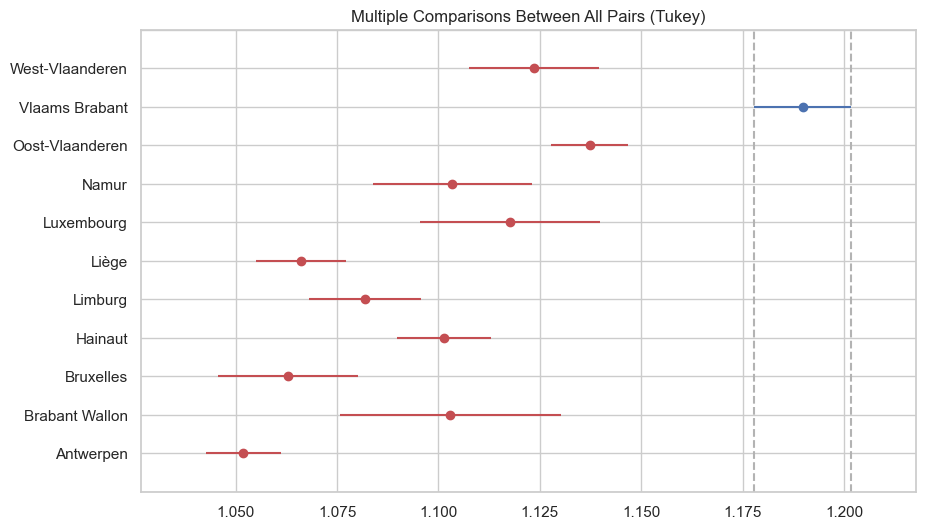

In [41]:
# Plot group confidence intervals
tukey2.plot_simultaneous(comparison_name='Vlaams Brabant');  

#### 5.2.3 Checking Model Assumptions

**Normality Of Residuals**

Kolmogorov-Smirnov Test: p-value = 0.0
Residuals do not appear to be normally distributed (reject H0).


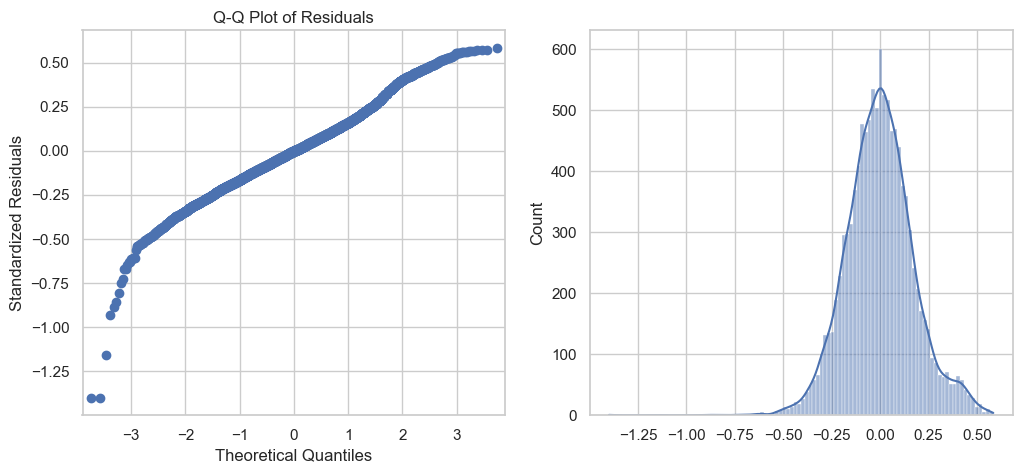

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normality of residuals with QQ-plot
residuals2 = model2.resid
sm.qqplot(residuals2, ax=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].set_xlabel("Theoretical Quantiles")
axes[0].set_ylabel("Standardized Residuals")

# Histogram
sns.histplot(residuals2, kde=True, ax=axes[1])

# Perform the Kolmogorov-Smirnov test for normality, because large dataset
ks_test2 = stats.kstest(residuals2, 'norm')

# Print the p-value
print('Kolmogorov-Smirnov Test: p-value =', ks_test2.pvalue)

# Interpret the result
if ks_test2.pvalue > 0.05:
    print("Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Residuals do not appear to be normally distributed (reject H0).")

**Homogeneity Of Variances**

p-value of the levene test:  1.894001077019482e-13
Variances across groups are not equal (reject H0).


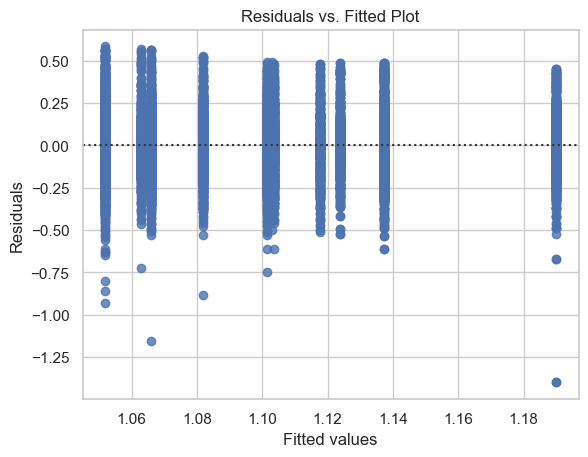

In [43]:
# Residuals vs Fitted Plot
fitted_vals2 = model2.fittedvalues
sns.residplot(x=fitted_vals2, y=residuals2, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Plot')


# Levene's test
# H0: population variances across groups are eaqual
levene_test2 = levene(rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Antwerpen'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Limburg'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Brabant Wallon'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Vlaams Brabant'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'West-Vlaanderen'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Hainaut'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Namur'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Liège'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Luxembourg'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Oost-Vlaanderen'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Bruxelles'])
print('p-value of the levene test: ', levene_test2[1])
# Interpret the result
if levene_test2.pvalue > 0.05:
    print("Variances across groups are equal (fail to reject H0).")
else:
    print("Variances across groups are not equal (reject H0).")

#### 5.2.4 Welch's ANOVA as alternative

**(Re)test Homogeneity of variances between the groups**

In [44]:
# Divide data in groups
p1 = rta_anova_prov[rta_anova_prov['Province'] == 'Antwerpen']
p2 = rta_anova_prov[rta_anova_prov['Province'] == 'Limburg']
p3 = rta_anova_prov[rta_anova_prov['Province'] == 'Brabant Wallon']
p4 = rta_anova_prov[rta_anova_prov['Province'] == 'Vlaams Brabant']
p5 = rta_anova_prov[rta_anova_prov['Province'] == 'West-Vlaanderen']
p6 = rta_anova_prov[rta_anova_prov['Province'] == 'Hainaut']
p7 = rta_anova_prov[rta_anova_prov['Province'] == 'Namur']
p8 = rta_anova_prov[rta_anova_prov['Province'] == 'Liège']
p9 = rta_anova_prov[rta_anova_prov['Province'] == 'Luxembourg']
p10 = rta_anova_prov[rta_anova_prov['Province'] == 'Oost-Vlaanderen']
p11 = rta_anova_prov[rta_anova_prov['Province'] == 'Bruxelles']

# Perform Bartlett's test to test homogeneity of variances between groups
barlett2 = stats.bartlett(p1['log_response_time'], p2['log_response_time'], p3['log_response_time'],
                         p4['log_response_time'], p5['log_response_time'], p6['log_response_time'],
                         p7['log_response_time'], p8['log_response_time'], p9['log_response_time'],
                         p10['log_response_time'], p11['log_response_time'],)

print('p-value =', barlett2.pvalue) # Rejected: assumption of equal variances is violated

p-value = 3.873194680170925e-11


**Welch's ANOVA if Homogeneity of Variances Rejected**

In [45]:
# Apply Welch's ANOVA
if barlett2.pvalue < 0.05:
    welch2 = pg.welch_anova(dv='log_response_time', between='Province', data=rta_anova_prov) 
welch2 # p-unc is the p-value; here: very small => reject the null hypothesis that the response time are equal between the eleven provinces.

,Source,ddof1,ddof2,F,p-unc,np2
0,Province,10,2587.460798,66.337529,1.198375e-120,0.056137


In [46]:
# If Welch's ANOVA significant:
# Games-Howell Post Hoc test for Welch's ANOVA
if welch2['p-unc'][0] < 0.05:
    gh2 = pg.pairwise_gameshowell(dv='log_response_time', between='Province', data=rta_anova_prov)
gh2

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Antwerpen,Brabant Wallon,1.051859,1.102941,-0.051082,0.012216,-4.181630,301.759328,1.863593e-03,-0.275305
1,Antwerpen,Bruxelles,1.051859,1.062790,-0.010931,0.008448,-1.293823,865.728622,9.698477e-01,-0.059459
2,Antwerpen,Hainaut,1.051859,1.101417,-0.049558,0.006003,-8.254902,2872.862493,9.364731e-13,-0.279907
3,Antwerpen,Limburg,1.051859,1.081942,-0.030082,0.007246,-4.151566,1577.268152,1.729928e-03,-0.163945
4,Antwerpen,Liège,1.051859,1.066003,-0.014144,0.006087,-2.323546,3047.635710,4.177972e-01,-0.078259
5,Antwerpen,Luxembourg,1.051859,1.117671,-0.065812,0.011832,-5.562229,435.863125,2.526942e-06,-0.347969
6,Antwerpen,Namur,1.051859,1.103447,-0.051588,0.009717,-5.308973,613.873718,8.335596e-06,-0.277471
7,Antwerpen,Oost-Vlaanderen,1.051859,1.137280,-0.085420,0.005400,-15.819112,4391.195328,1.654565e-12,-0.476273
8,Antwerpen,Vlaams Brabant,1.051859,1.189902,-0.138043,0.006409,-21.539589,2460.817389,5.748735e-13,-0.762328
9,Antwerpen,West-Vlaanderen,1.051859,1.123670,-0.071811,0.007768,-9.244449,1084.731104,8.393286e-14,-0.394273


**Visualization of the p-values in the form of a Heatmap**

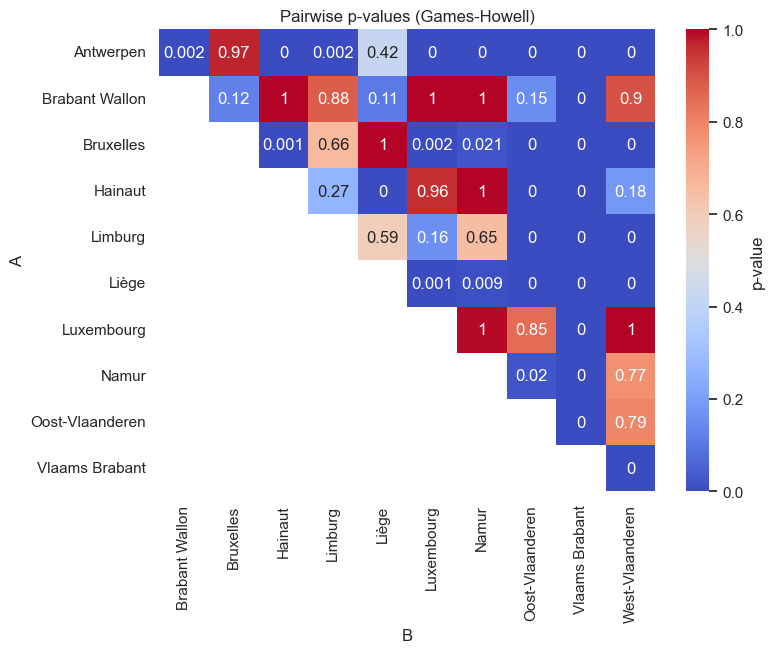

In [47]:
# Pivot the results to get the p-values
pval_matrix2 = gh2.pivot(index='A', columns='B', values='pval').round(3)

# Plot the heatmap
sns.set(style='white')
plt.figure(figsize=(8, 6))
sns.heatmap(pval_matrix2, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
plt.title('Pairwise p-values (Games-Howell)')
plt.show()

After checking the model assumptions for a one-way ANOVA, we saw that the normality of the residuals and the homogeneity of the variances between the provinces weren't equal. So, the results of the ANOVA may be incorrect or misleading. 

Because the homogeneity was not met (see also Barlett's test) an alternative test was performed, namely the Welch's ANOVA. This test gave, just as the one-way ANOVA a significant result, indicating the (mean) response time for the different vector types aren't equal. As post hoc test, a Games-Howell test was executed to see where the differences lie.

**Result**

Most remarkable observation is that the response time in Vlaams Brabant is significantly different from all others. The province Vlaams Brabant has the longest response times, on average 16.6 minutes. Antwerp, Brussels and Liège have the lowest response times, almost significantly smaller than all other provinces.

### 5.3 Response Time versus Event Level

#### 5.3.1 Summary Statistics & Visualisation

In [48]:
# Discard rows with Missing Values for vector type
rta_anova_el = rta_anova[['response_time', 'Eventlevel']].dropna()
rta_anova_el.reset_index(drop=True, inplace=True) # Reset index after dropping missing values

# Make Event level categorical
rta_anova_el['Eventlevel'] = rta_anova_el['Eventlevel'].astype('category')

# Log-Transform the variable Response Time, because is right-skewed
rta_anova_el['log_response_time'] = np.nan # Initialize new column for transformed response times
rta_anova_el.loc[:,'log_response_time'] = np.log10(rta_anova_el['response_time'])

print(len(rta_anova),len(rta_anova_el)) # 0 observations with missing province removed

11181 11181


In [49]:
# Basics Statistics per Group
rta_ready.groupby('Eventlevel')['response_time'].describe()

,count,mean,std,min,25%,50%,75%,max
Eventlevel,,,,,,,,
0.0,1556.0,12.429032,5.624388,1.572733,8.703717,11.244700,14.736503,41.248764
1.0,8071.0,14.088128,6.284937,0.616667,9.895975,12.869567,16.683242,43.566667
2.0,606.0,13.233226,5.557587,1.556450,9.484958,12.274458,15.501550,42.604350
5.0,884.0,13.800447,5.970434,2.253300,9.731975,12.517775,16.389079,42.837061
6.0,59.0,16.279690,6.363564,2.631367,11.393308,15.002997,18.604408,36.973533
7.0,5.0,20.090010,1.772889,18.218717,18.962533,20.163583,20.226750,22.878467


Text(0, 0.5, 'Response Time')

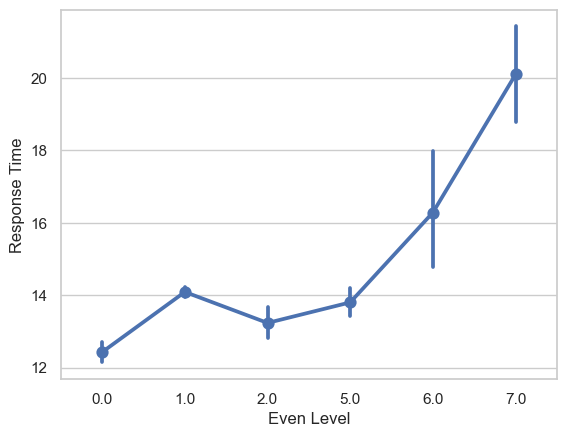

In [50]:
sns.set(style='whitegrid')
sns.pointplot(x='Eventlevel', y = 'response_time', data = rta_ready) # errorbars: 95% confidence interval
plt.xlabel('Even Level')
plt.ylabel('Response Time')

#### 5.3.2 Perform Analysis

In [51]:
# ANOVA
formula3 = 'log_response_time ~ Eventlevel'
model3 = ols(formula3, data=rta_anova_el).fit()
anova_table3 = sm.stats.anova_lm(model3, typ=2)
anova_table3

,sum_sq,df,F,PR(>F)
Eventlevel,4.558239,5.0,28.266211,1.425986e-28
Residual,360.418419,11175.0,NaN,NaN


In [52]:
# Post-hoc test if ANOVA is significant
# Tukey's honestly significantly differneced (HSD) test
# H0: No significant difference between the means of two groups
if anova_table3['PR(>F)'].iloc[0] < 0.05:
    tukey3 = pairwise_tukeyhsd(rta_anova_el['log_response_time'], rta_anova_el['Eventlevel'], alpha=0.05)

tukey3.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
0.0,1.0,0.0543,0.0,0.0402,0.0685,True
0.0,2.0,0.0296,0.0075,0.0051,0.0541,True
0.0,5.0,0.0475,0.0,0.026,0.0691,True
0.0,6.0,0.1227,0.0,0.0548,0.1906,True
0.0,7.0,0.245,0.0282,0.0157,0.4743,True
1.0,2.0,-0.0247,0.0139,-0.0463,-0.0031,True
1.0,5.0,-0.0068,0.8924,-0.025,0.0113,False
1.0,6.0,0.0683,0.0419,0.0014,0.1352,True
1.0,7.0,0.1907,0.1658,-0.0383,0.4196,False
2.0,5.0,0.0179,0.4096,-0.0091,0.0449,False


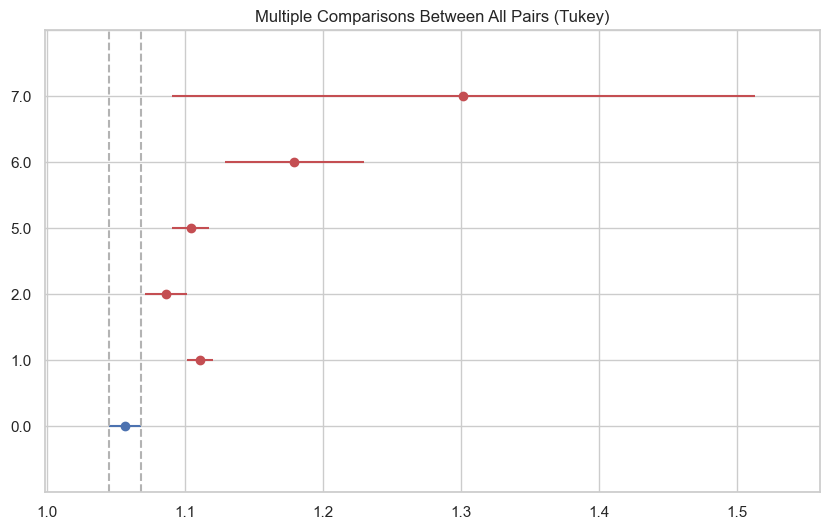

In [53]:
# Plot group confidence intervals
tukey3.plot_simultaneous(comparison_name=0.0);    

#### 5.3.3 Checking Model Assumptions

**Normality Of Residuals**

Kolmogorov-Smirnov Test: p-value = 0.0
Residuals do not appear to be normally distributed (reject H0).


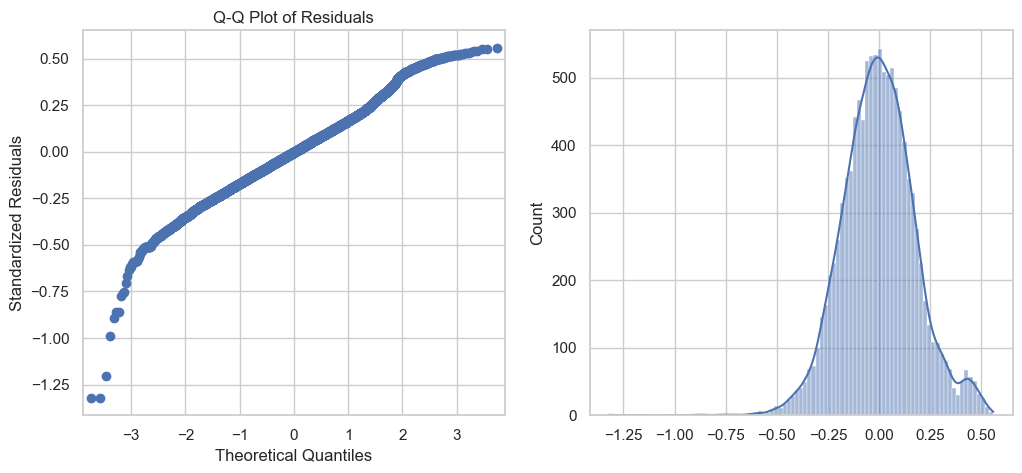

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normality of residuals with QQ-plot
residuals3 = model3.resid
sm.qqplot(residuals3, ax=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].set_xlabel("Theoretical Quantiles")
axes[0].set_ylabel("Standardized Residuals")

# Histogram
sns.histplot(residuals3, kde=True, ax=axes[1])

# Perform the Kolmogorov-Smirnov test for normality, because large dataset
ks_test3 = stats.kstest(residuals3, 'norm')

# Print the p-value
print('Kolmogorov-Smirnov Test: p-value =', ks_test3.pvalue)

# Interpret the result
if ks_test3.pvalue > 0.05:
    print("Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Residuals do not appear to be normally distributed (reject H0).")

**Homogeneity Of Variances**

p-value of the levene test:  0.2375809300392625
Variances across groups are equal (fail to reject H0).


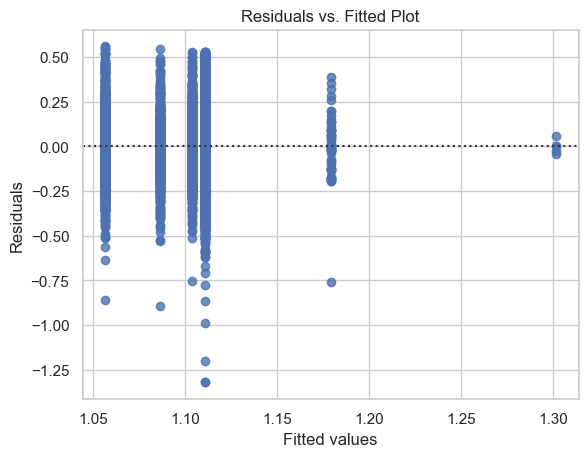

In [55]:
# Residuals vs Fitted Plot
fitted_vals3 = model3.fittedvalues
sns.residplot(x=fitted_vals3, y=residuals3, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Plot')


# Levene's test
# H0: population variances across groups are eaqual
levene_test3 = levene(rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 0.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 1.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 2.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 5.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 6.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 7.0])
print('p-value of the levene test: ', levene_test3[1])
# Interpret the result
if levene_test3.pvalue > 0.05:
    print("Variances across groups are equal (fail to reject H0).")
else:
    print("Variances across groups are not equal (reject H0).")

#### 5.2.4 Welch's ANOVA as alternative

**(Re)test Homogeneity of variances between the groups**

In [56]:
# Divide data in groups
el1 = rta_anova_el[rta_anova_el['Eventlevel'] == 0.0]
el2 = rta_anova_el[rta_anova_el['Eventlevel'] == 1.0]
el3 = rta_anova_el[rta_anova_el['Eventlevel'] == 2.0]
el4 = rta_anova_el[rta_anova_el['Eventlevel'] == 5.0]
el5 = rta_anova_el[rta_anova_el['Eventlevel'] == 6.0]
el6 = rta_anova_el[rta_anova_el['Eventlevel'] == 7.0]

# Perform Bartlett's test to test homogeneity of variances between groups
barlett3 = stats.bartlett(el1['log_response_time'], el2['log_response_time'], el3['log_response_time'],
                         el4['log_response_time'], el5['log_response_time'], el6['log_response_time'])

print('p-value =', barlett3.pvalue)

p-value = 0.05722705980179388


**Welch's ANOVA if Homogeneity of Variances Rejected**

In [57]:
# Apply Welch's ANOVA
# Here homogeneity of variances between groups borderline accepted.
# But still a Welch's ANOVA was perfromed.
welch3 = pg.welch_anova(dv='log_response_time', between='Eventlevel', data=rta_anova_el) 
welch3 # p-unc is the p-value; here: very small => reject the null hypothesis that the response time are equal between the eleven provinces.

,Source,ddof1,ddof2,F,p-unc,np2
0,Eventlevel,5,44.039429,52.29084,2.031055e-17,0.012489


In [58]:
# If Welch's ANOVA significant:
# Games-Howell Post Hoc test for Welch's ANOVA
if welch3['p-unc'][0] < 0.05:
    gh3 = pg.pairwise_gameshowell(dv='log_response_time', between='Eventlevel', data=rta_anova_el)
gh3

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,0.0,1.0,1.056666,1.111006,-0.054340,0.004954,-10.968803,2211.535494,0.000000e+00,-0.301450
1,0.0,2.0,1.056666,1.086301,-0.029635,0.008502,-3.485568,1111.168865,6.753025e-03,-0.166239
2,0.0,5.0,1.056666,1.104183,-0.047516,0.007416,-6.407639,1869.724201,2.796295e-09,-0.268110
3,0.0,6.0,1.056666,1.179337,-0.122671,0.023368,-5.249434,62.609943,2.783705e-05,-0.686820
4,0.0,7.0,1.056666,1.301667,-0.245001,0.017365,-14.108579,4.604832,3.876287e-04,-1.372705
5,1.0,2.0,1.111006,1.086301,0.024705,0.007471,3.306654,702.750552,1.267760e-02,0.136993
6,1.0,5.0,1.111006,1.104183,0.006823,0.006207,1.099308,1100.306021,8.817320e-01,0.037909
7,1.0,6.0,1.111006,1.179337,-0.068331,0.023013,-2.969173,58.894942,4.710584e-02,-0.378467
8,1.0,7.0,1.111006,1.301667,-0.190661,0.016885,-11.291940,4.115806,1.835455e-03,-1.056089
9,2.0,5.0,1.086301,1.104183,-0.017882,0.009288,-1.925228,1287.840588,3.870540e-01,-0.101757


**Visualization of the p-values in the form of a Heatmap**

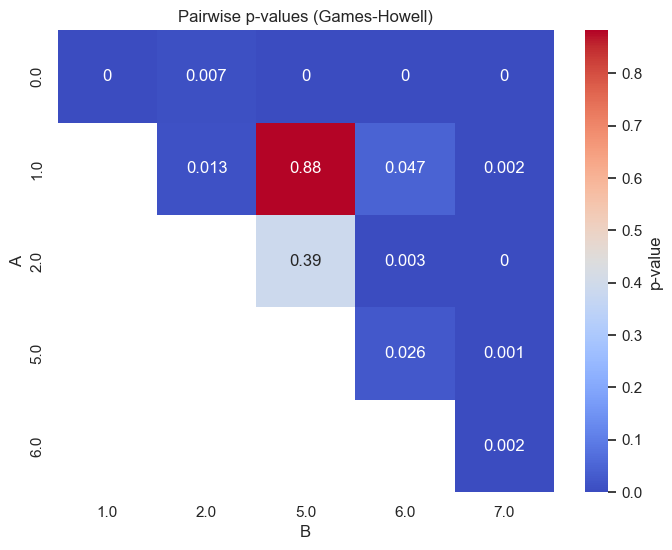

In [59]:
# Pivot the results to get the p-values
pval_matrix3 = gh3.pivot(index='A', columns='B', values='pval').round(3)

# Plot the heatmap
sns.set(style='white')
plt.figure(figsize=(8, 6))
sns.heatmap(pval_matrix3, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
plt.title('Pairwise p-values (Games-Howell)')
plt.show()

After checking the model assumptions for a one-way ANOVA, we saw that the normality of the residuals was violated. However, the homogeneity of the variances between the provinces where a doubtful case. So, the results of the ANOVA may be incorrect or misleading. 

Because the significance of the Barlett's test was on the edge, the alternative test was also performed, namely the Welch's ANOVA. This test gave, just as the one-way ANOVA a significant result, indicating the (mean) response time for the different vector types aren't equal. As post hoc test, a Games-Howell test was executed to see where the differences lie.

**Result**

Most remarkable observation is that the mean response times for the extreme event levels, level zero and level seven, differ significantly from the other levels. Here level seven has the longest mean response times and level zero the shortest. Mean response times for event level six also differ significantly from all the other groups. This could indicate that a level zero cardiac arrest is worse than a level seven cardiac arrest. 